<a href="https://colab.research.google.com/github/PaolinaCastany/Master_Thesis/blob/main/ThesisPart1_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thesis — Part 1

Data acquisition (KaggleHub) + cleaning + genre selection + dataset exports + saved figures.

In [ ]:
# Mount Drive + create project folders
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_FOLDER = "/content/drive/MyDrive/Thesis_Music_Success"
PATHS = {
    'data': os.path.join(BASE_FOLDER, 'data'),
    'plots': os.path.join(BASE_FOLDER, 'plots'),
    'results': os.path.join(BASE_FOLDER, 'results'),
    'models': os.path.join(BASE_FOLDER, 'models')
}
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

print("Folders ready:")
for k,v in PATHS.items():
    print(k, "->", v)


Mounted at /content/drive
Folders ready:
data -> /content/drive/MyDrive/Thesis_Music_Success/data
plots -> /content/drive/MyDrive/Thesis_Music_Success/plots
results -> /content/drive/MyDrive/Thesis_Music_Success/results
models -> /content/drive/MyDrive/Thesis_Music_Success/models


In [ ]:
# Imports + helpers
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def save_data(df, filename):
    fp = os.path.join(PATHS['data'], filename)
    df.to_csv(fp, index=False)
    print("✅ Saved:", fp)

def save_plot(filename):
    fp = os.path.join(PATHS['plots'], filename)
    plt.tight_layout()
    plt.savefig(fp, dpi=300, bbox_inches='tight')
    print("✅ Saved plot:", fp)


In [ ]:
# 1) Download dataset via KaggleHub
import kagglehub

print("Downloading dataset from KaggleHub...")
path = kagglehub.dataset_download("amitanshjoshi/spotify-1million-tracks")
print("Dataset downloaded to:", path)

# Find a CSV inside
import glob
csvs = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
if not csvs:
    raise FileNotFoundError("No CSV found inside the downloaded KaggleHub dataset folder.")
csv_path = csvs[0]
print("Using CSV:", csv_path)

df = pd.read_csv(csv_path)
print("Raw shape:", df.shape)
df.head()


100%|██████████| 77.1M/77.1M [00:00<00:00, 109MB/s] 

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/amitanshjoshi/spotify-1million-tracks/versions/1
Using CSV: /root/.cache/kagglehub/datasets/amitanshjoshi/spotify-1million-tracks/versions/1/spotify_data.csv
Raw shape: (1159764, 20)


,Unnamed: 0,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3
1,1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4
2,2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4
3,3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4
4,4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4


✅ Saved plot: /content/drive/MyDrive/Thesis_Music_Success/plots/01_initial_exploration.png


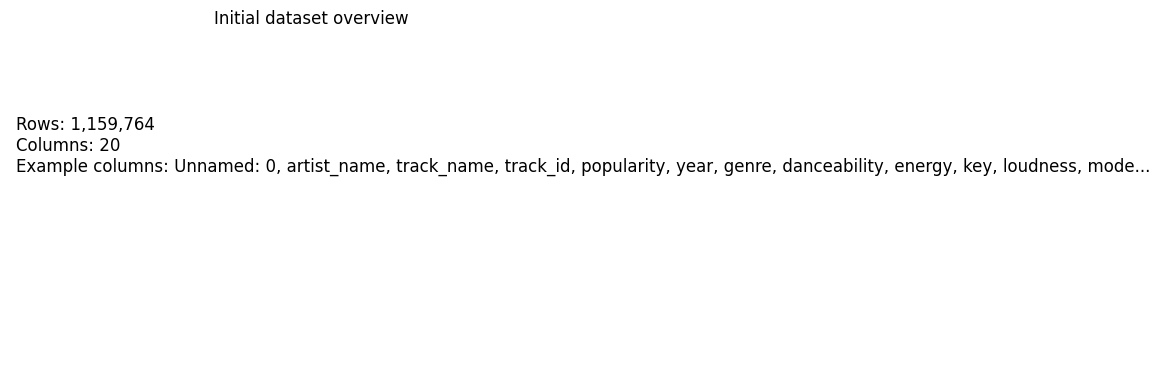

In [ ]:
# 2) Initial exploration figure
plt.figure(figsize=(10,4))
plt.title("Initial dataset overview")
plt.axis('off')
txt = f"""Rows: {len(df):,}
Columns: {df.shape[1]}
Example columns: {', '.join(list(df.columns[:12]))}{'...' if len(df.columns)>12 else ''}"""
plt.text(0.01, 0.6, txt, fontsize=12)
save_plot('01_initial_exploration.png')
plt.show()


In [ ]:
# 3) Cleaning + feature engineering (keeps structure compatible with later notebooks)
df_clean = df.copy()
initial_size = len(df_clean)

# Common noisy columns in this dataset
for col in ['Unnamed: 0', 'track_id']:
    if col in df_clean.columns:
        df_clean = df_clean.drop(col, axis=1)

# Drop rows missing essential IDs/names if present
for col in ['track_name', 'artist_name']:
    if col in df_clean.columns:
        df_clean = df_clean.dropna(subset=[col])

# De-duplicate by track + artist if available
if 'track_name' in df_clean.columns and 'artist_name' in df_clean.columns:
    df_clean = df_clean.drop_duplicates(subset=['track_name', 'artist_name'], keep='first')

# Popularity bounds
if 'popularity' in df_clean.columns:
    df_clean = df_clean[df_clean['popularity'].between(0,100)]

# Duration minutes if duration_ms exists
if 'duration_ms' in df_clean.columns and 'duration_mins' not in df_clean.columns:
    df_clean['duration_mins'] = df_clean['duration_ms'] / 60000

# Regression target improvement (log1p)
df_clean['popularity_log'] = np.log1p(df_clean['popularity'])

print(f"Cleaned: {initial_size:,} -> {len(df_clean):,}")
save_data(df_clean, 'spotify_cleaned.csv')
df_clean.head()


Cleaned: 1,159,764 -> 1,159,748
✅ Saved: /content/drive/MyDrive/Thesis_Music_Success/data/spotify_cleaned.csv


,artist_name,track_name,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,duration_mins,popularity_log
0,Jason Mraz,I Won't Give Up,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3,4.002767,4.234107
1,Jason Mraz,93 Million Miles,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4,3.606450,3.931826
2,Joshua Hyslop,Do Not Let Me Go,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4,2.649333,4.060443
3,Boyce Avenue,Fast Car,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4,5.071550,4.077537
4,Andrew Belle,Sky's Still Blue,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4,4.072000,4.007333


✅ Saved plot: /content/drive/MyDrive/Thesis_Music_Success/plots/02_feature_distributions.png


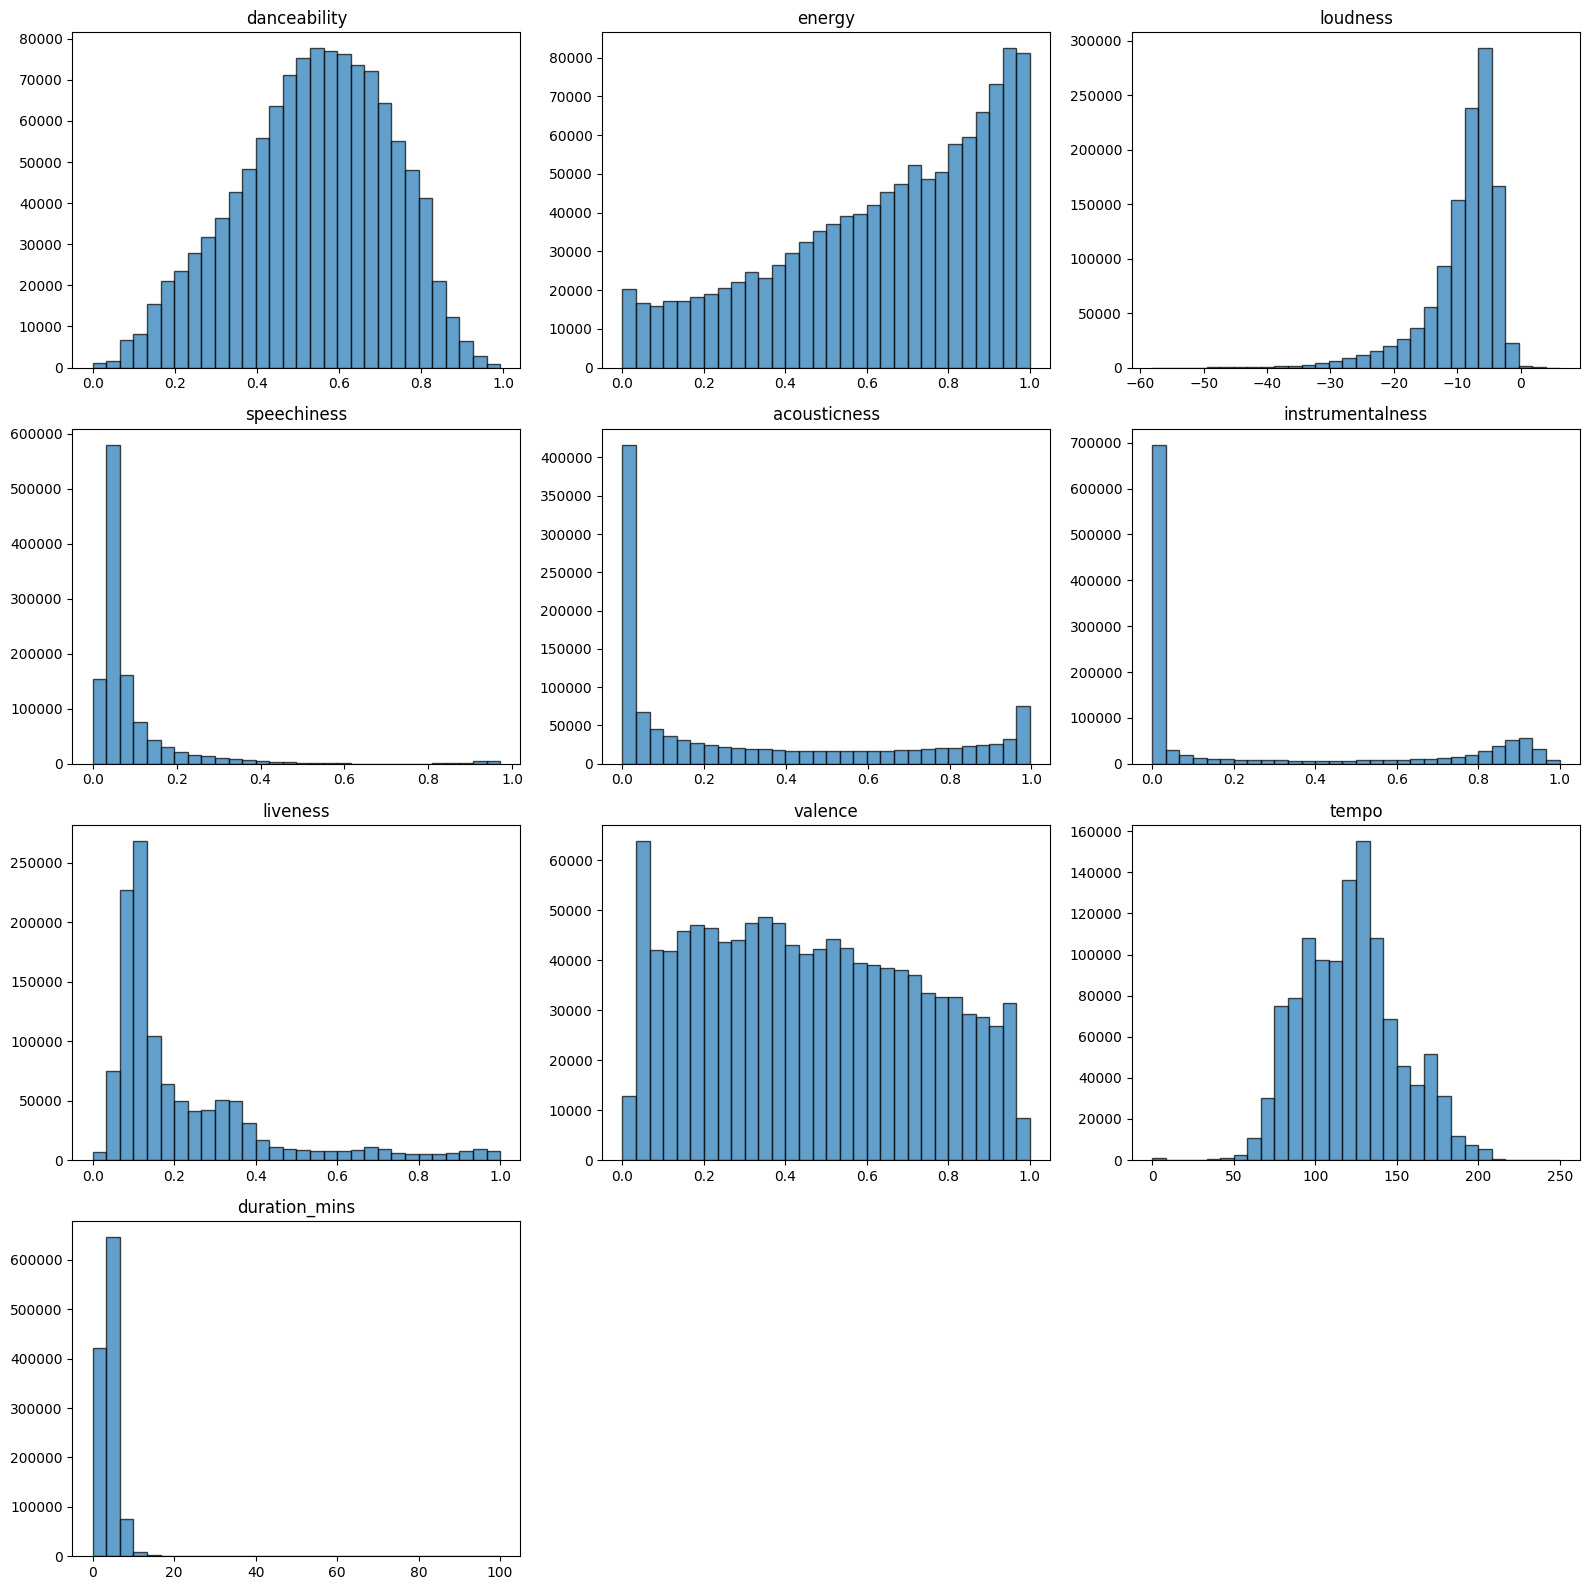

In [ ]:
# 4) Feature distributions figure (uses typical audio features if present)
audio_features = [
    'danceability','energy','loudness','speechiness','acousticness',
    'instrumentalness','liveness','valence','tempo'
]
audio_features = [c for c in audio_features if c in df_clean.columns]
if 'duration_mins' in df_clean.columns:
    audio_features.append('duration_mins')

n = len(audio_features)
cols = 3
rows = int(np.ceil(n/cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = np.array(axes).reshape(-1)

for i, feat in enumerate(audio_features):
    axes[i].hist(df_clean[feat].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(feat)
for j in range(i+1, len(axes)):
    axes[j].axis('off')

save_plot('02_feature_distributions.png')
plt.show()


✅ Saved plot: /content/drive/MyDrive/Thesis_Music_Success/plots/03_correlation_matrix.png


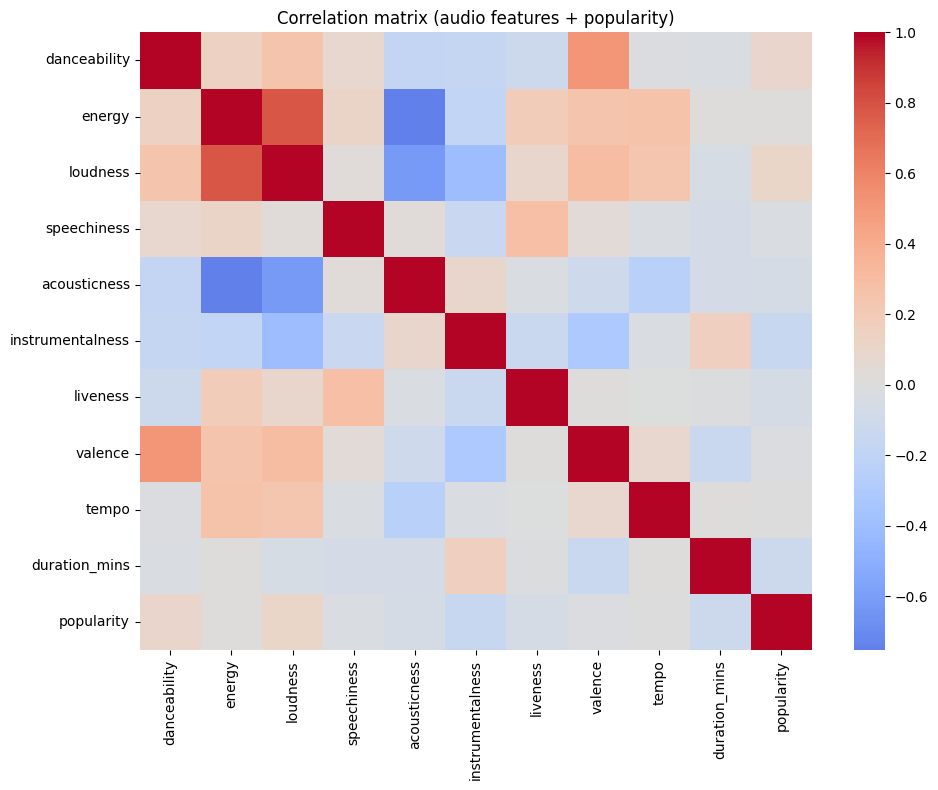

In [ ]:
# 5) Correlation matrix figure (audio features vs popularity)
corr_cols = [c for c in audio_features if c in df_clean.columns] + ['popularity']
corr_cols = [c for c in corr_cols if c in df_clean.columns]
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation matrix (audio features + popularity)")
save_plot('03_correlation_matrix.png')
plt.show()


Selected genres: ['black-metal', 'gospel', 'ambient', 'acoustic', 'alt-rock', 'emo', 'indian', 'k-pop']
Filtered shape: (168294, 20)
✅ Saved plot: /content/drive/MyDrive/Thesis_Music_Success/plots/04_genre_distribution.png


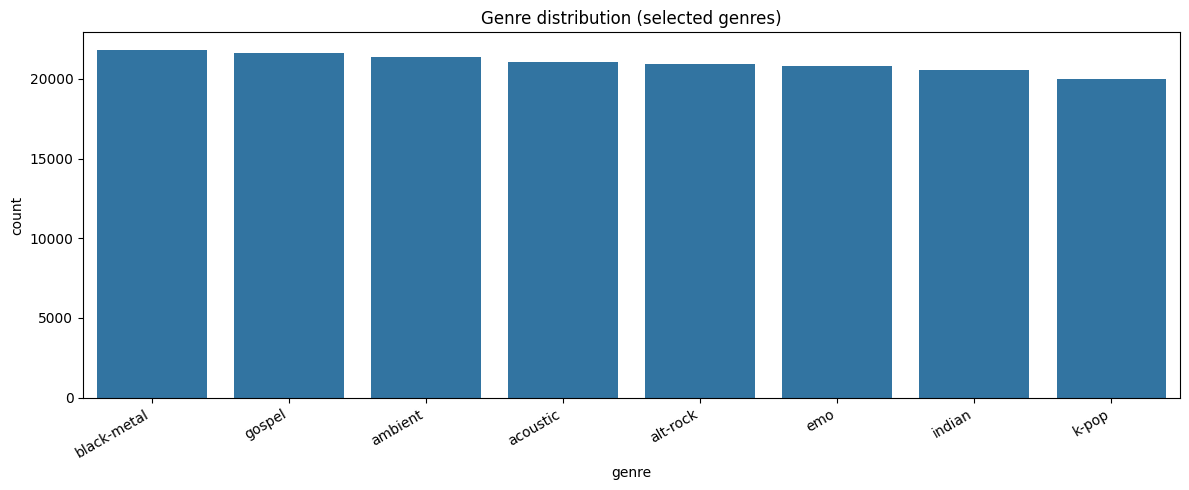

In [ ]:
# 6) Genre selection + filtered dataset
if 'genre' not in df_clean.columns:
    raise ValueError("Expected a 'genre' column in the dataset for genre filtering.")

MIN_TRACKS = 15000
MAX_GENRES = 8

genre_counts = df_clean['genre'].value_counts()
valid_genres = genre_counts[genre_counts >= MIN_TRACKS]
selected_genres = valid_genres.head(MAX_GENRES).index.tolist()

print("Selected genres:", selected_genres)

df_filtered = df_clean[df_clean['genre'].isin(selected_genres)].copy()
print("Filtered shape:", df_filtered.shape)

# Genre distribution plot
plt.figure(figsize=(12,5))
sns.countplot(data=df_filtered, x='genre', order=selected_genres)
plt.xticks(rotation=30, ha='right')
plt.title("Genre distribution (selected genres)")
save_plot('04_genre_distribution.png')
plt.show()


✅ Saved plot: /content/drive/MyDrive/Thesis_Music_Success/plots/05_target_distribution.png


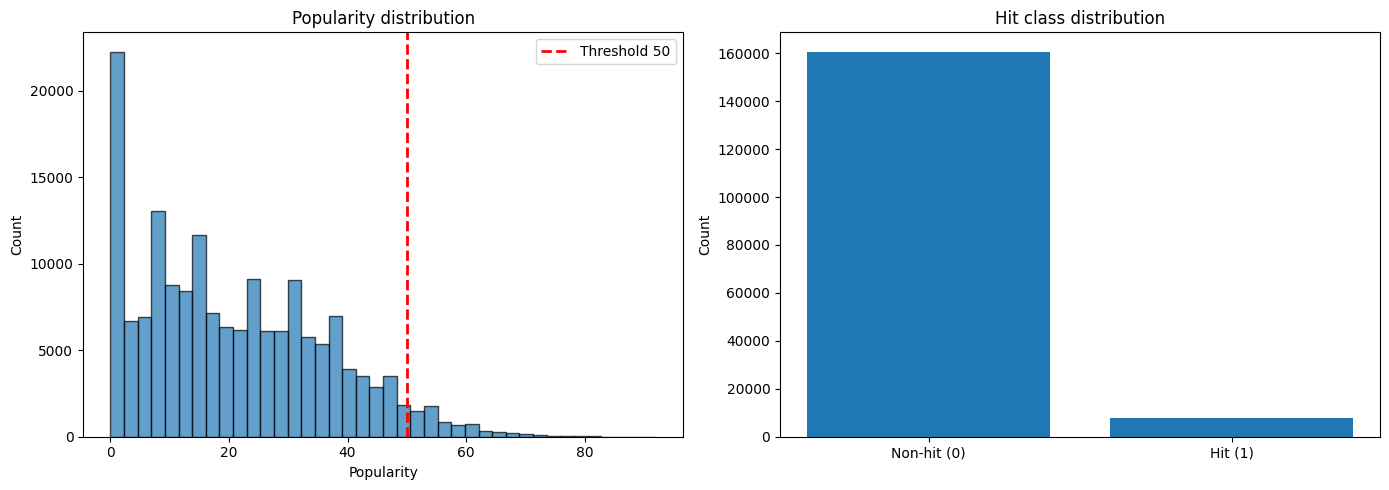

In [ ]:
# 7) Targets: binary hit + distributions figure
HIT_THRESHOLD = 50
df_filtered['is_hit'] = (df_filtered['popularity'] >= HIT_THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(df_filtered['popularity'], bins=40, edgecolor='black', alpha=0.7)
axes[0].axvline(HIT_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold {HIT_THRESHOLD}')
axes[0].set_title("Popularity distribution")
axes[0].set_xlabel("Popularity")
axes[0].set_ylabel("Count")
axes[0].legend()

hit_counts = df_filtered['is_hit'].value_counts().sort_index()
axes[1].bar(['Non-hit (0)','Hit (1)'], hit_counts.values)
axes[1].set_title("Hit class distribution")
axes[1].set_ylabel("Count")

save_plot('05_target_distribution.png')
plt.show()


✅ Saved: /content/drive/MyDrive/Thesis_Music_Success/data/spotify_final.csv
✅ Saved: /content/drive/MyDrive/Thesis_Music_Success/data/spotify_train.csv
✅ Saved: /content/drive/MyDrive/Thesis_Music_Success/data/spotify_test.csv
✅ Saved plot: /content/drive/MyDrive/Thesis_Music_Success/plots/06_genre_statistics.png


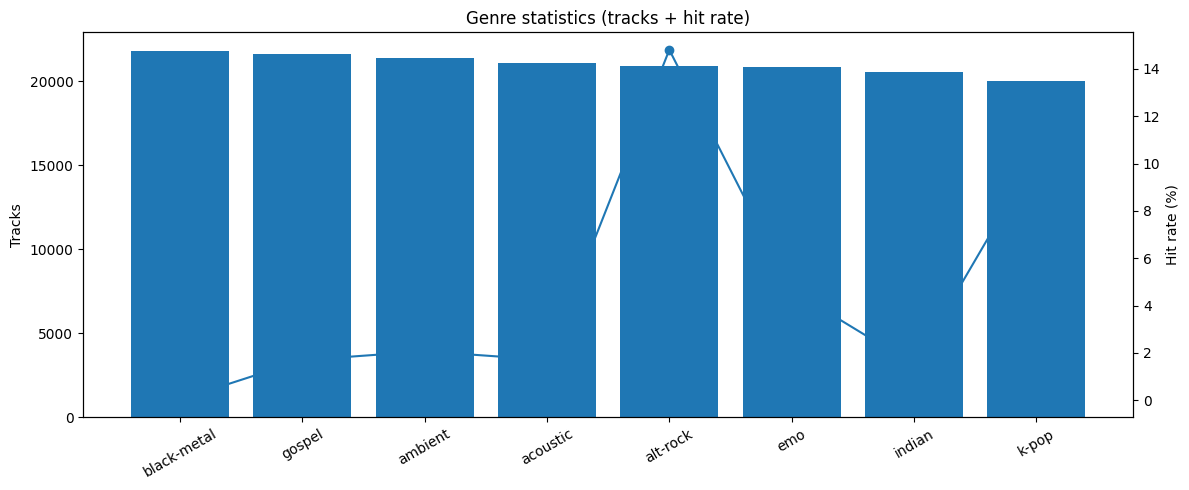

,genre,tracks,hit_rate_%,mean_popularity
0,black-metal,21837,0.027476,11.082658
1,gospel,21621,1.697424,18.920401
2,ambient,21389,2.071158,20.008743
3,acoustic,21097,1.706404,17.825094
4,alt-rock,20918,14.810211,38.596807
5,emo,20845,4.643799,23.661981
6,indian,20583,1.501239,8.790458
7,k-pop,20004,10.347930,27.736203


In [ ]:
# 8) Train/test split by year + save datasets + genre stats figure
TEST_YEAR = 2019
df_train = df_filtered[df_filtered['year'] < TEST_YEAR].copy()
df_test  = df_filtered[df_filtered['year'] >= TEST_YEAR].copy()

save_data(df_filtered, 'spotify_final.csv')
save_data(df_train, 'spotify_train.csv')
save_data(df_test, 'spotify_test.csv')

# Genre statistics figure
stats = []
for g in selected_genres:
    gdf = df_filtered[df_filtered['genre']==g]
    stats.append({
        "genre": g,
        "tracks": len(gdf),
        "hit_rate_%": gdf['is_hit'].mean()*100,
        "mean_popularity": gdf['popularity'].mean()
    })
stats_df = pd.DataFrame(stats).sort_values("tracks", ascending=False)

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.bar(stats_df['genre'], stats_df['tracks'])
ax1.set_ylabel("Tracks")
ax1.set_title("Genre statistics (tracks + hit rate)")
ax1.tick_params(axis='x', rotation=30)

ax2 = ax1.twinx()
ax2.plot(stats_df['genre'], stats_df['hit_rate_%'], marker='o')
ax2.set_ylabel("Hit rate (%)")

save_plot('06_genre_statistics.png')
plt.show()

stats_df
